In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('VERİ.xlsx')

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["DayName"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [5]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [6]:
df_sales = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0) & (df["CustomerID"].notna())].copy()

In [7]:
df_returns = df[(df["Quantity"] < 0) | (df["InvoiceNo"].astype(str).str.startswith("C"))].copy()
df_returns["TotalPrice"] = df_returns["TotalPrice"].abs()

In [8]:
df_sales['CustomerID'] = df_sales['CustomerID'].astype(int).astype(str)

In [9]:
df_sales.dropna(subset=["Description"], inplace=True)
df_returns.dropna(subset=["Description"], inplace=True)

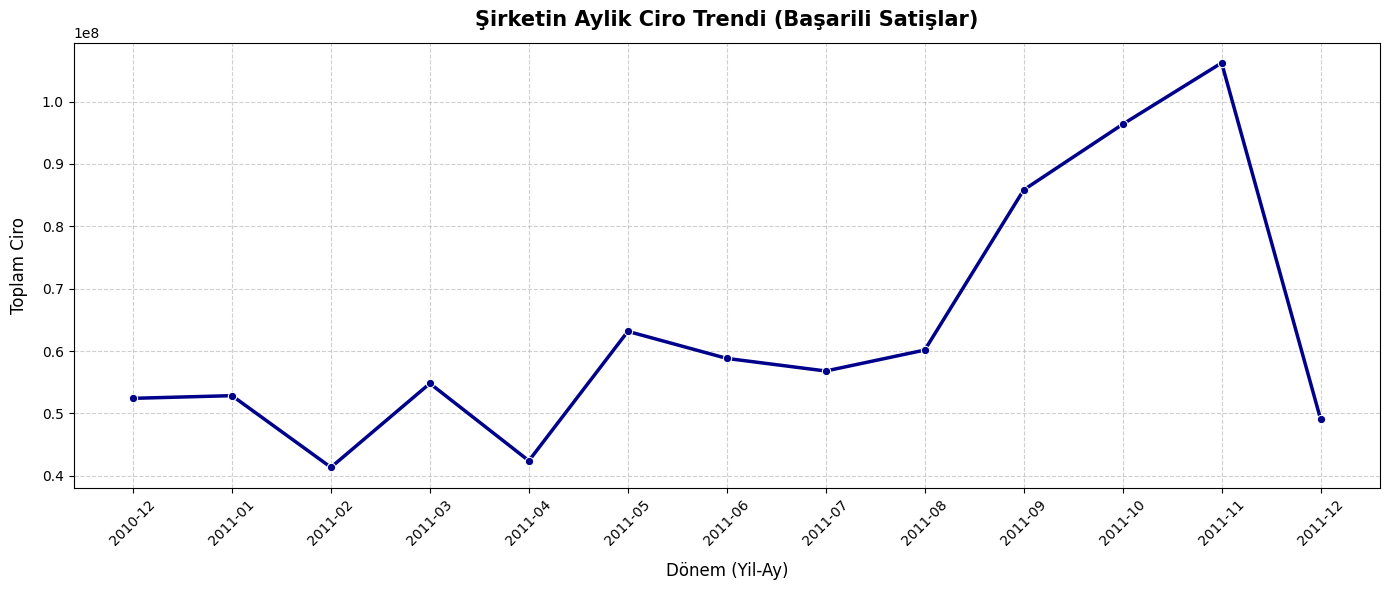

In [10]:
aylik_ciro = df_sales.groupby(["Year", "Month"])["TotalPrice"].sum().reset_index()
aylik_ciro["Period"] = aylik_ciro["Year"].astype(str) + "-" + aylik_ciro["Month"].astype(str).str.zfill(2)
aylik_ciro = aylik_ciro.sort_values("Period")
plt.figure(figsize=(14, 6))
sns.lineplot(data=aylik_ciro, x="Period", y="TotalPrice", marker="o", color="darkblue", linewidth=2.5)
plt.title("Şirketin Aylik Ciro Trendi (Başarili Satişlar)", fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Dönem (Yil-Ay)", fontsize=12, labelpad=10)
plt.ylabel("Toplam Ciro", fontsize=12, labelpad=10)
plt.xticks(rotation=45) 
plt.grid(True, linestyle="--", alpha=0.6) 
plt.tight_layout()
plt.show()

In [11]:
bugun = df_sales["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df_sales.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (bugun - x.max()).days, 
    "InvoiceNo": "nunique",                         
    "TotalPrice": "sum"                             
}).reset_index()
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]


In [12]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1, 2, 3, 4, 5])
rfm["RF_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str)


In [13]:
seg_map = {
    r"[1-2][1-2]": "Hibernating",
    r"[1-2][3-4]": "At Risk",
    r"[1-2]5": "Cant Lose Them",
    r"3[1-2]": "About to Sleep",
    r"33": "Need Attention",
    r"[3-4][4-5]": "Loyal Customers",
    r"41": "Promising",
    r"51": "New Customers",
    r"[4-5][2-3]": "Potential Loyalists",
    r"5[4-5]": "Champions"
}
rfm["Segment"] = rfm["RF_Score"].replace(seg_map, regex=True)


C:\Users\BATUHAN-PC\AppData\Local\Temp\ipykernel_16364\3163549697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y="Segment", order=rfm["Segment"].value_counts().index, palette="Set2")


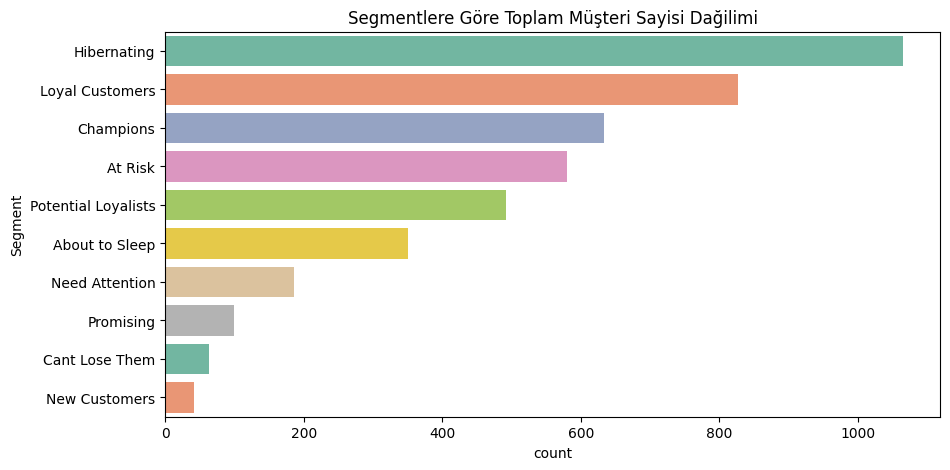

In [14]:

plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y="Segment", order=rfm["Segment"].value_counts().index, palette="Set2")
plt.title("Segmentlere Göre Toplam Müşteri Sayisi Dağilimi")
plt.show()

C:\Users\BATUHAN-PC\AppData\Local\Temp\ipykernel_16364\1680217333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm, x="Monetary", y="Segment", estimator=sum,errorbar="ci" ,palette="Spectral")


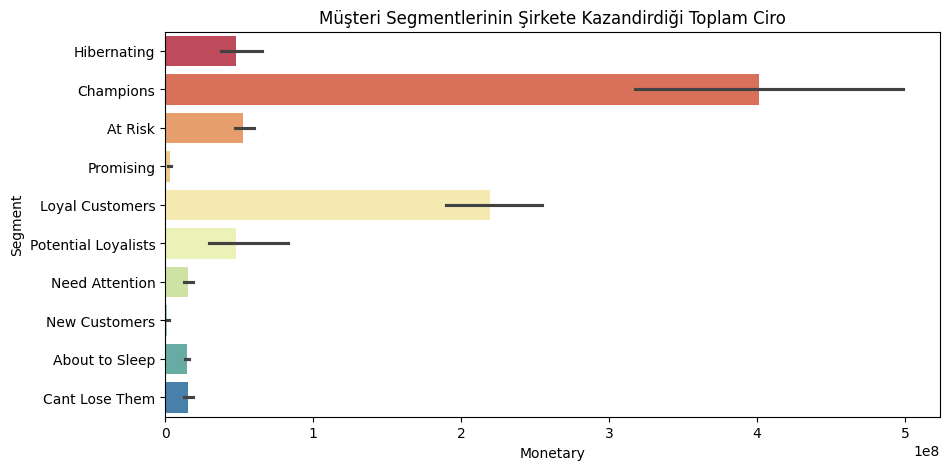

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm, x="Monetary", y="Segment", estimator=sum,errorbar="ci" ,palette="Spectral")
plt.title("Müşteri Segmentlerinin Şirkete Kazandirdiği Toplam Ciro")
plt.show()

C:\Users\BATUHAN-PC\AppData\Local\Temp\ipykernel_16364\694552491.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iade_orani, x="Return_Rate", y="Country", palette="Reds_r")


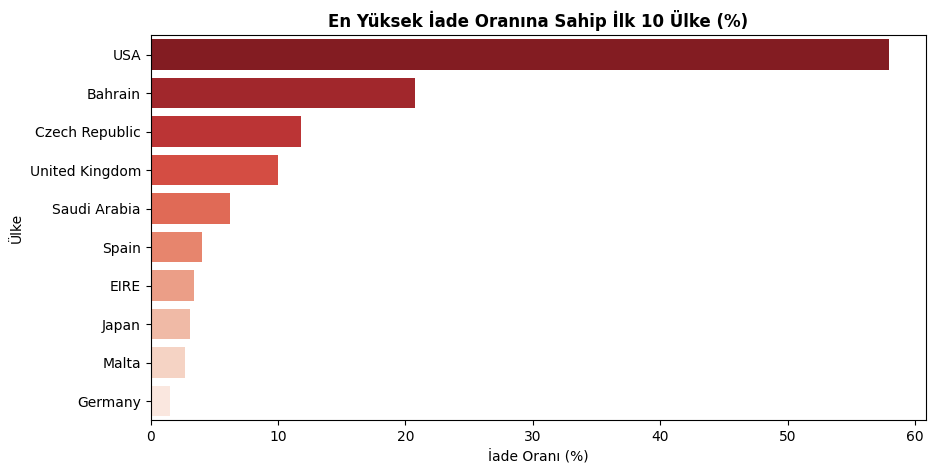

In [16]:
ulke_satis = df_sales.groupby("Country")["Quantity"].sum()
ulke_iade = abs(df_returns.groupby("Country")["Quantity"].sum())
iade_orani = ((ulke_iade / ulke_satis) * 100).sort_values(ascending=False).head(10).reset_index()
iade_orani.columns = ["Country", "Return_Rate"]


plt.figure(figsize=(10, 5))
sns.barplot(data=iade_orani, x="Return_Rate", y="Country", palette="Reds_r")

plt.title("En Yüksek İade Oranına Sahip İlk 10 Ülke (%)", fontsize=12, fontweight="bold")
plt.xlabel("İade Oranı (%)")
plt.ylabel("Ülke")
plt.show()

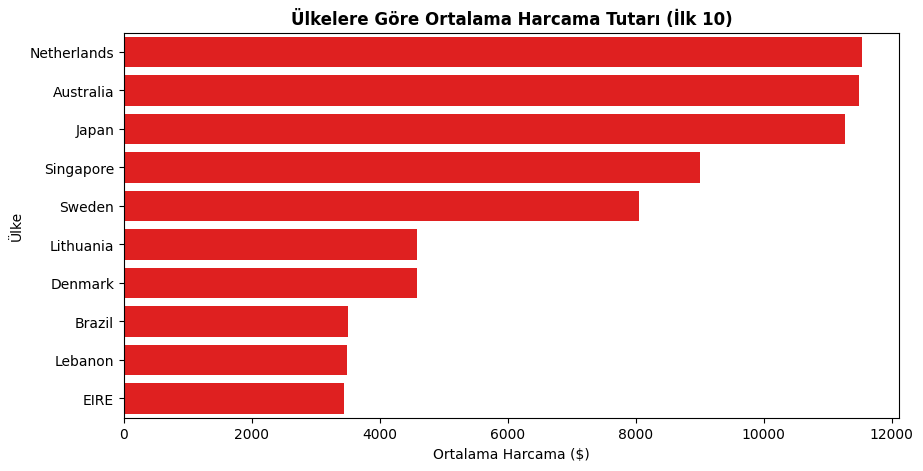

In [39]:
df_country = df_sales.groupby("Country").agg({"TotalPrice":"mean","Quantity":"mean"}).reset_index().sort_values(by="TotalPrice", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_country, x="TotalPrice", y="Country", color="red")

plt.title("Ülkelere Göre Ortalama Harcama Tutarı (İlk 10)", fontsize=12, fontweight="bold")
plt.xlabel("Ortalama Harcama ($)")
plt.ylabel("Ülke")
plt.show()

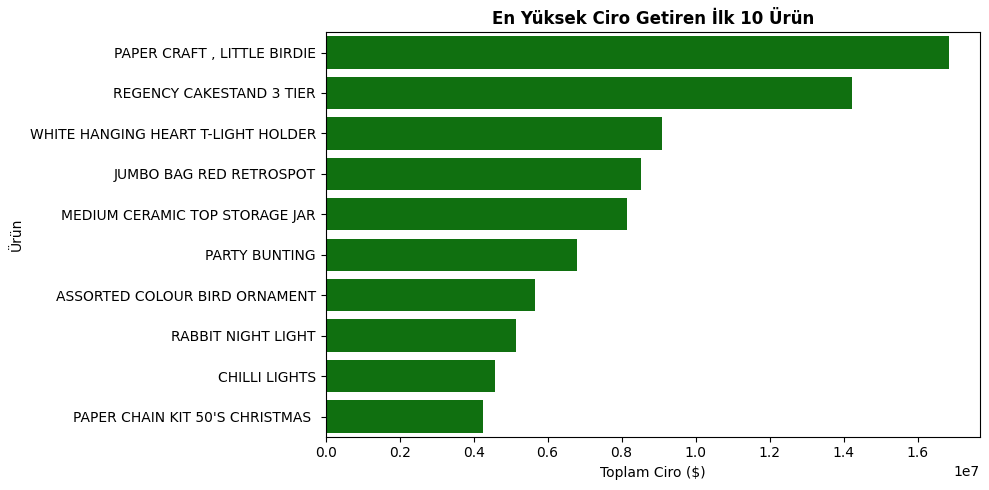

In [40]:

df_products = df_sales.groupby("Description")["TotalPrice"].sum().reset_index().sort_values(by="TotalPrice", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_products, x="TotalPrice", y="Description", color="green")

plt.title("En Yüksek Ciro Getiren İlk 10 Ürün", fontsize=12, fontweight="bold")
plt.xlabel("Toplam Ciro ($)")
plt.ylabel("Ürün")
plt.tight_layout() 
plt.show()

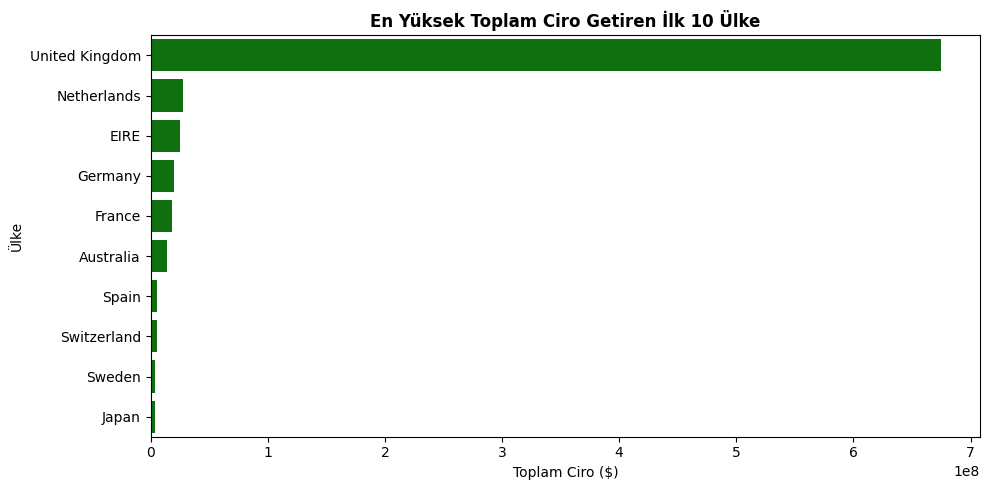

In [41]:
df_top_countries = df_sales.groupby("Country")["TotalPrice"].sum().reset_index().sort_values(by="TotalPrice", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_countries, x="TotalPrice", y="Country", color="green")

plt.title("En Yüksek Toplam Ciro Getiren İlk 10 Ülke", fontsize=12, fontweight="bold")
plt.xlabel("Toplam Ciro ($)")
plt.ylabel("Ülke")
plt.tight_layout() 
plt.show()

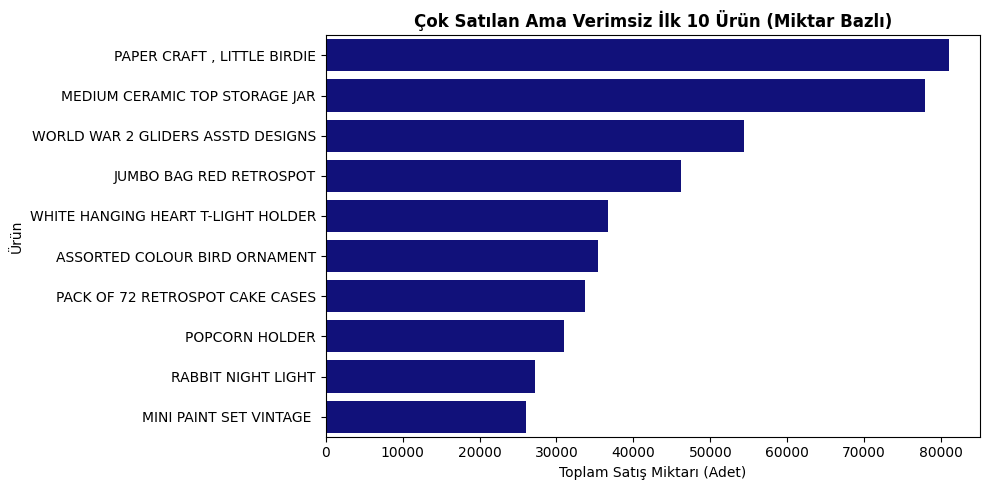

In [42]:
urun_performans = df_sales.groupby("Description").agg({"Quantity":"sum","TotalPrice":"sum","UnitPrice":"mean"}).reset_index()
cok_satilanlar = urun_performans[urun_performans["Quantity"]>10000].copy()
verimsiz_urunler = cok_satilanlar.sort_values(by=["Quantity","TotalPrice"],ascending=[False,True])

df_verimsiz = verimsiz_urunler.head(10)


plt.figure(figsize=(10, 5))
sns.barplot(data=df_verimsiz, x="Quantity", y="Description", color="darkblue")

plt.title("Çok Satılan Ama Verimsiz İlk 10 Ürün (Miktar Bazlı)", fontsize=12, fontweight="bold")
plt.xlabel("Toplam Satış Miktarı (Adet)")
plt.ylabel("Ürün")
plt.tight_layout() 
plt.show()

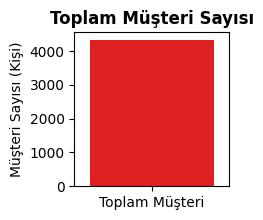

In [44]:
toplam_musteri = df_sales["CustomerID"].nunique()

plt.figure(figsize=(2, 2))
sns.barplot(x=["Toplam Müşteri"], y=[toplam_musteri], color="red")

plt.title("Toplam Müşteri Sayısı", fontsize=12, fontweight="bold")
plt.ylabel("Müşteri Sayısı (Kişi)")
plt.show()

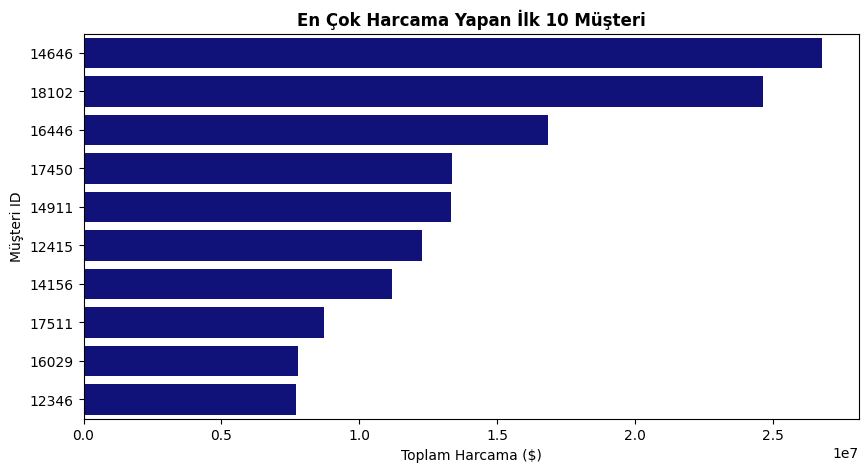

In [45]:
en_cok_harcayan_musteriler = df_sales.groupby("CustomerID")["TotalPrice"].sum().reset_index().sort_values(by="TotalPrice", ascending=False).head(10)


plt.figure(figsize=(10, 5))
sns.barplot(data=en_cok_harcayan_musteriler, x="TotalPrice", y=en_cok_harcayan_musteriler["CustomerID"].astype(str), color="darkblue")

plt.title("En Çok Harcama Yapan İlk 10 Müşteri", fontsize=12, fontweight="bold")
plt.xlabel("Toplam Harcama ($)")
plt.ylabel("Müşteri ID")
plt.show()